# `Student Support & Early-Warning Analytics System`

### `Goal: Predict which students are "at risk" (Fail/Withdrawn) using academic engagement and demographic data so instructors can intervene early.`

### `Dataset: UCI Open University Learning Analytics Dataset (OULAD)`

### `Model: Random Forest Classifier | Accuracy: 90.4%`

In [2]:
# Importing All required Libraries of Python.

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
# Importing all the Tables with Pandas.                         Total Tables

student_info = pd.read_csv('studentInfo.csv')                        #1

student_assessment = pd.read_csv('studentAssessment.csv')            #2

assessments = pd.read_csv('assessments.csv')                         #3

student_vle = pd.read_csv('studentVle.csv')                          #4

course = pd.read_csv('courses.csv')                                  #5

vle = pd.read_csv('vle.csv')                                         #6

student_registration = pd.read_csv('studentRegistration.csv')        #7

#  `EDA --> student_info Table`

`Data Inspection`

In [4]:
# Total rows

student_info.shape

(32593, 12)

In [5]:
# Overview of student_info Table 

student_info.head(5)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [6]:
# Description 

student_info.describe()

,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


In [7]:
# Information

student_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              32593 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


`Data Cleaning & Preprocessing`

In [8]:
# Checking Duplicates

student_info.duplicated(subset= ['code_module','code_presentation','id_student']).sum()

np.int64(0)

`No Real Duplicates found`

`Composite key ('code_module', 'code_presentation', 'id_student') par 0 duplicates hain, 
jisse pata chalta hai ki har row ek student ki specific course aur semester ki unique enrollment ko represent karti hai.`

In [9]:
# Checking Nulls

student_info.isnull().sum()

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64

`No nulls detected`

`Checking missing values Using uniuqe()`

In [10]:
student_info['imd_band'].unique()

<StringArray>
['90-100%',  '20-30%',  '30-40%',  '50-60%',  '80-90%',  '70-80%',       '?',
  '60-70%',  '40-50%',   '10-20',   '0-10%']
Length: 11, dtype: str

In [11]:
student_info['imd_band'] = student_info['imd_band'].str.strip().replace('?', 'Unknown')

# Checking the value counts of the result column to know how many student failed or passed.

In [12]:
student_info['final_result'] = student_info['final_result'].str.replace('Distinction', 'Top Performer')

In [13]:
student_info['final_result'].value_counts().reset_index()

,final_result,count
0,Pass,12361
1,Withdrawn,10156
2,Fail,7052
3,Top Performer,3024


# Checking the Value Count of students for Highest Qualification 

In [14]:
student_info['highest_education'].value_counts().reset_index()

,highest_education,count
0,A Level or Equivalent,14045
1,Lower Than A Level,13158
2,HE Qualification,4730
3,No Formal quals,347
4,Post Graduate Qualification,313


# Visualazing `Final Result` based on `Gender.`

In [15]:
result_by_gender = pd.crosstab(student_info['final_result'], student_info['gender'])

result_by_gender

gender,F,M
final_result,,
Fail,3103,3949
Pass,5735,6626
Top Performer,1394,1630
Withdrawn,4486,5670


<Figure size 1200x600 with 0 Axes>

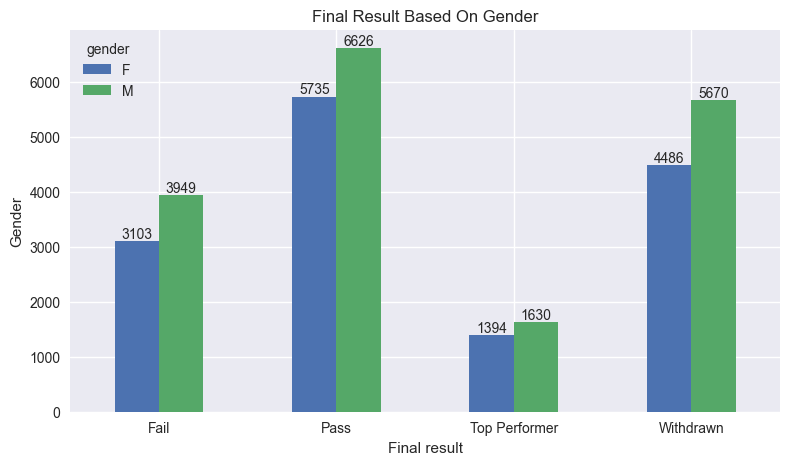

In [16]:
from matplotlib import container
from sympy import rotations


plt.figure(figsize = (12,6))

plt.style.use('seaborn-v0_8')


ax = result_by_gender.plot(kind = 'bar')

for container in ax.containers:
    ax.bar_label(container)
    

plt.title('Final Result Based On Gender')

plt.xlabel('Final result')
plt.ylabel('Gender')

plt.tight_layout()

plt.xticks(rotation = 0)

plt.show()

# ` Total Number of students` According to the `age group` and `Male and Female`

In [17]:
Total_students_by_age_and_gender = student_info.groupby(['age_band','gender'])['id_student'].nunique()

Total_students_by_age_and_gender.reset_index()

,age_band,gender,id_student
0,0-35,F,9422
1,0-35,M,10756
2,35-55,F,4317
3,35-55,M,4183
4,55<=,F,21
5,55<=,M,158


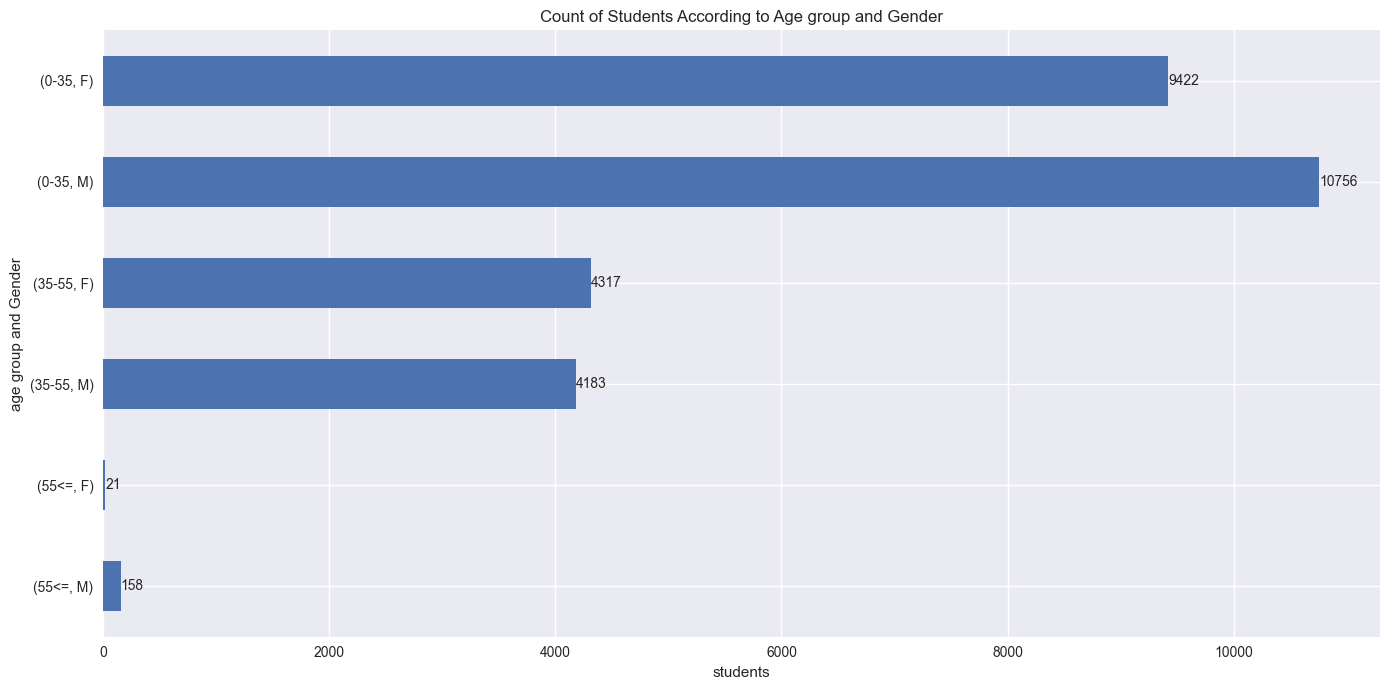

In [18]:
plt.figure(figsize=(14,7))

plt.style.use('seaborn-v0_8')

ax = Total_students_by_age_and_gender.plot(kind = 'barh')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Count of Students According to Age group and Gender')    

plt.xlabel('students')

plt.ylabel('age group and Gender')

ax.invert_yaxis()

plt.tight_layout()

plt.show()

## `EDA of student_info() is completed`

# `======================================================================================================================
# =======================================================================================================================`

## `EDA` ---> `student_vle`

In [19]:
# Total rows 

student_vle.shape

(10655280, 6)

`Above 10 Million or 1 crore rows`

In [20]:
# Descrioption and Stastics 

student_vle.describe()

,id_student,id_site,date,sum_click
count,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
mean,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00
max,2.698588e+06,1.049562e+06,2.690000e+02,6.977000e+03


In [21]:
# Info 

student_vle.info()

<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB


In [22]:
# Overview

student_vle.head(5)

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


# `Data cleaning and Preprocessing`

In [23]:
# Checking for duplicate values and also taking overview of the duplicated rows by using keep = False.

student_vle[student_vle.duplicated(keep = False)].sort_values(by = ['code_module', 'code_presentation', 'id_student', 'id_site', 'date']).head(5)

,code_module,code_presentation,id_student,id_site,date,sum_click
169286,AAA,2013J,11391,546644,231,7
169287,AAA,2013J,11391,546644,231,7
80310,AAA,2013J,11391,546650,82,2
80311,AAA,2013J,11391,546650,82,2
6760,AAA,2013J,11391,546652,-5,1


In [24]:
# Checking total duplicates

student_vle.duplicated().sum()

np.int64(787170)

In [25]:
# Droping All Duplicates

student_vle = student_vle.drop_duplicates()   

In [26]:
# Checking for Nulls

student_vle.isnull().sum()

code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

` No Nulls detected `

# `EDA DONE of student_vle `

# `=======================================================================================================
# ========================================================================================================`

# `EDA -->  vle Table`

In [27]:
# Total rows 

vle.shape

(6364, 6)

In [28]:
# Overview

vle.head(5)

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?


In [29]:
# Description and Statstics

vle.describe()

,id_site
count,6.364000e+03
mean,7.260991e+05
std,1.283151e+05
min,5.267210e+05
25%,6.615928e+05
50%,7.300965e+05
75%,8.140162e+05
max,1.077905e+06


In [30]:
# Info and Data types

vle.info()

<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_site            6364 non-null   int64
 1   code_module        6364 non-null   str  
 2   code_presentation  6364 non-null   str  
 3   activity_type      6364 non-null   str  
 4   week_from          6364 non-null   str  
 5   week_to            6364 non-null   str  
dtypes: int64(1), str(5)
memory usage: 298.4 KB


`So week from and week to columns should be int data type but they include str charcter ->  '?' so we have to replace it with Null.`

In [31]:
# Replacing ? with null.

vle[['week_from','week_to']] = vle[['week_from','week_to']].replace('?',np.nan)

In [32]:
# Checking 

vle['week_from'].unique()

<StringArray>
[ nan,  '2',  '1',  '9', '11', '22',  '6',  '8', '19',  '4', '15', '14', '25',
 '20', '27', '16', '24',  '3', '21', '18', '26', '10',  '5', '28', '23', '13',
 '12',  '7', '17',  '0', '29']
Length: 31, dtype: str

In [33]:
# Converting the columns from string to integer 

from numpy import int64


vle[['week_from','week_to']] = vle[['week_from','week_to']].astype('Int64')  # Used capital Int64 for nan values specially to avoid error

In [34]:
# Checking for Duplicates

vle.duplicated().sum()

np.int64(0)

### `No duplicates in Table --> vle`

In [35]:
# Checking for Nulls

vle.isnull().sum()

id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64

### `There are no nulls in Table except the nulls that we delibrately put in place of '?' in columns -> week_from & week_to.`

# `EDA done for Table --> vle`

# `=============================================================================================================
# ==============================================================================================================`

# Merging Both Tables --->  `student_vle` and  `vle` Together.

In [36]:
# Checking comman columns for student_vle
student_vle.columns

Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='str')

In [37]:
# Checking comman columns for student_vle
vle.columns

Index(['id_site', 'code_module', 'code_presentation', 'activity_type',
       'week_from', 'week_to'],
      dtype='str')

In [38]:
# Merging using column columns inside on and using left join.

vle_tables_merged = pd.merge(student_vle, vle, on= ['id_site','code_module','code_presentation'], how = 'left')

In [39]:
# OVERVIEW OF MERGED TABLES

vle_tables_merged.head(5)

,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type,week_from,week_to
0,AAA,2013J,28400,546652,-10,4,forumng,<NA>,<NA>
1,AAA,2013J,28400,546652,-10,1,forumng,<NA>,<NA>
2,AAA,2013J,28400,546614,-10,11,homepage,<NA>,<NA>
3,AAA,2013J,28400,546714,-10,1,oucontent,<NA>,<NA>
4,AAA,2013J,28400,546652,-10,8,forumng,<NA>,<NA>


# `Visulaizations`

### `Which activity type is used to most in terms of "clicks".`

In [40]:
most_clicked_activity = vle_tables_merged.groupby('activity_type')['sum_click'].sum().sort_values(ascending = False).head(10)

most_clicked_activity.reset_index()

,activity_type,sum_click
0,oucontent,11078195
1,forumng,7272356
2,homepage,6949064
3,quiz,6635922
4,subpage,3411582
5,resource,1074948
6,ouwiki,869443
7,url,566702
8,oucollaborate,100304
9,glossary,87928


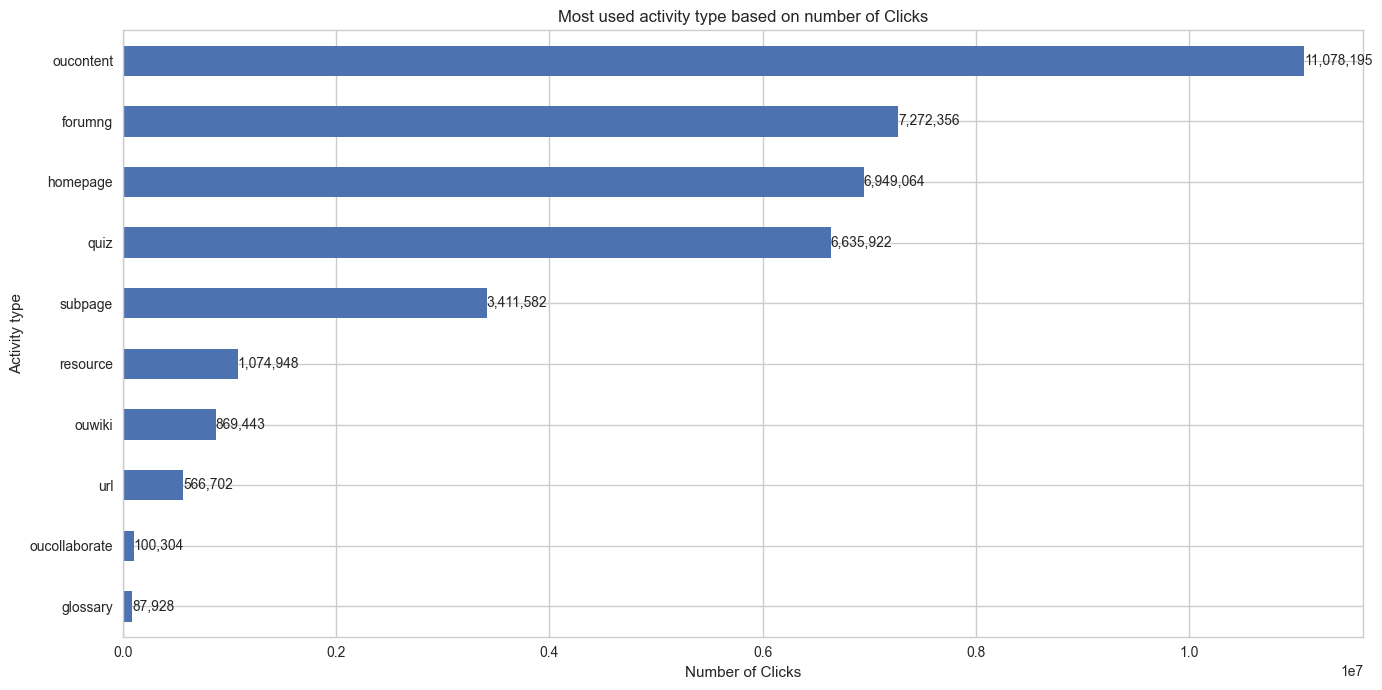

In [41]:

plt.style.use('seaborn-v0_8-whitegrid')


ax = most_clicked_activity.plot(y = 'activity_type', x = 'sum_click',kind = 'barh',figsize = (14,7))

ax.bar_label(ax.containers[0],fmt='{:,.0f}')

ax.invert_yaxis()

plt.title('Most used activity type based on number of Clicks')

plt.ylabel('Activity type')
plt.xlabel('Number of Clicks')

plt.tight_layout()

plt.show()

### `How many uniuqe students use the which activity type`

In [42]:
most_activity_type_used_by_stuednts = vle_tables_merged.groupby('activity_type')['id_student'].nunique().sort_values(ascending = False).head(10)

most_activity_type_used_by_stuednts

activity_type
homepage         26037
subpage          25343
resource         24896
oucontent        24281
forumng          23512
url              21488
quiz             18291
ouwiki           10402
oucollaborate    10288
page              8327
Name: id_student, dtype: int64

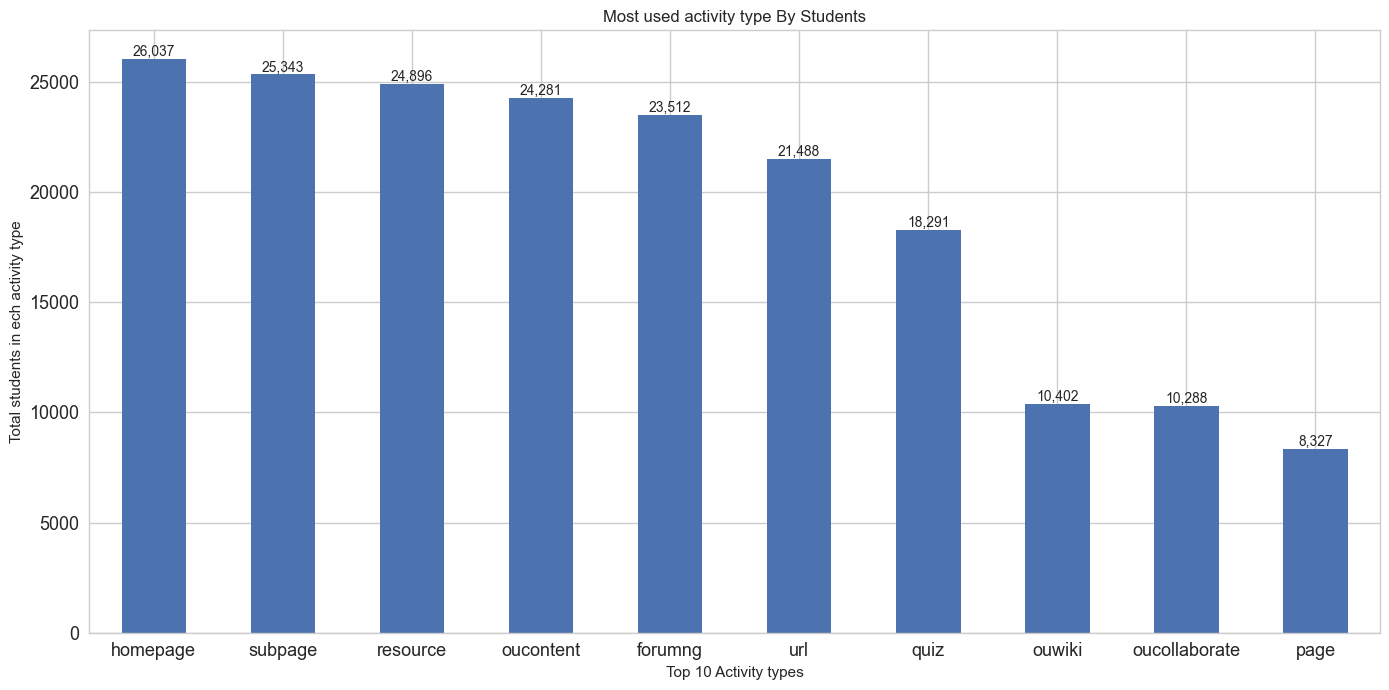

In [43]:
from huggingface_hub import Padding


ax = most_activity_type_used_by_stuednts.plot(kind = 'bar', figsize = (14,7), fontsize = 13)

ax.bar_label(ax.containers[0],fmt='{:,.0f}')

plt.title('Most used activity type By Students')

plt.xlabel('Top 10 Activity types')
plt.ylabel('Total students in ech activity type')

plt.style.use('ggplot')

plt.xticks(rotation = 0)

plt.tight_layout()

plt.show()

# `EDA DONE`

# `================================================================================================================
# ================================================================================================================`

# `EDA --> course Table `

In [44]:
# Total rows and columns 

course.shape

(22, 3)

In [45]:
# Overview Of course Table

course.head(5)

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


### ` Data Cleaning and Preprocessing`

In [46]:
# Checking for Duplicates

course.duplicated().sum()

np.int64(0)

In [47]:
# Checking for Nulls

course.isnull().sum()

code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

# `Visualization`

In [48]:
average_course_length = course.groupby('code_module')['module_presentation_length'].mean().sort_values(ascending=False).round()

average_course_length

code_module
AAA    268.0
EEE    259.0
GGG    257.0
CCC    255.0
FFF    254.0
BBB    251.0
DDD    251.0
Name: module_presentation_length, dtype: float64

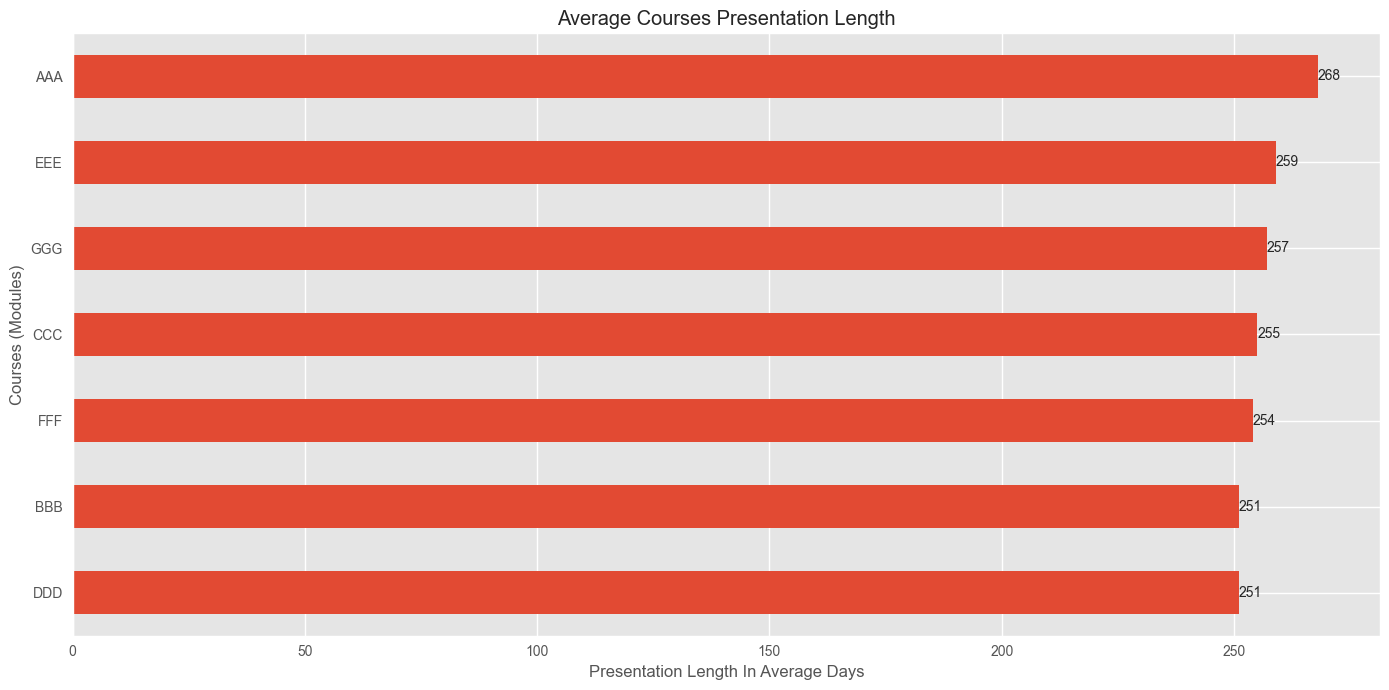

In [49]:
ax = average_course_length.plot(kind = 'barh', figsize=(14,7))

ax.bar_label(ax.containers[0])

ax.invert_yaxis()

plt.title('Average Courses Presentation Length')

plt.ylabel('Courses (Modules)')
plt.xlabel('Presentation Length In Average Days')

plt.style.use('seaborn-v0_8-muted')

plt.tight_layout()

plt.show()

# `EDA DONE`

# `================================================================================================================
# =================================================================================================================`

# `EDA ---> assessments Table`

In [50]:
# Total rows and columns 

assessments.shape

(206, 6)

In [51]:
# Overview of assessments table

assessments.head(5)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


In [52]:
# Description and Stastics

assessments.describe()

,id_assessment,weight
count,206.000000,206.000000
mean,26473.975728,20.873786
std,10098.625521,30.384224
min,1752.000000,0.000000
25%,15023.250000,0.000000
50%,25364.500000,12.500000
75%,34891.750000,24.250000
max,40088.000000,100.000000


In [53]:
# Information and Data types

assessments.info()

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               206 non-null    str    
 5   weight             206 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 9.8 KB


`date column contains integeer values but it's data type is string`

In [54]:
# Checking for reason

assessments['date'].unique()

<StringArray>
[ '19',  '54', '117', '166', '215',   '?',  '89', '124', '159', '187',  '47',
  '96', '131', '208',  '82', '152', '194',  '12',  '40', '110', '201',  '18',
  '67', '137', '207',  '32', '102', '151', '200', '144', '214', '109', '158',
  '23',  '51',  '79', '114', '149', '170', '206',  '25',  '53',  '81', '116',
 '240',  '88', '123', '165', '261',  '74', '241',  '20',  '41',  '62', '111',
 '146', '195',  '33',  '68', '235', '228', '222', '236', '173', '227',  '24',
  '52',  '87', '129', '171',  '94', '136', '199', '229',  '61']
Length: 75, dtype: str

`We have to replace '?' with null and then convert it into integer data type`

In [55]:
# Replacing and removing extra whitespaces.

assessments['date'] = assessments['date'].str.strip().replace('?',np.nan)

In [56]:
# Converting from string to interger data type using capital Int64

from numpy import astype


assessments['date'] = assessments['date'].astype('Int64')

In [57]:
# Checking for Duplicates

assessments.duplicated().sum()

np.int64(0)

In [58]:
# Checking for Nulls

assessments.isnull().sum() 

code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

`These 11 nuls in date column are the ones we delibrately put in `

# `Visulizations`

In [59]:
most_weighted_assignemnts = assessments.groupby('assessment_type')['weight'].mean().sort_values(ascending = False).round().head(10)

most_weighted_assignemnts

assessment_type
Exam    100.0
TMA      17.0
CMA       1.0
Name: weight, dtype: float64

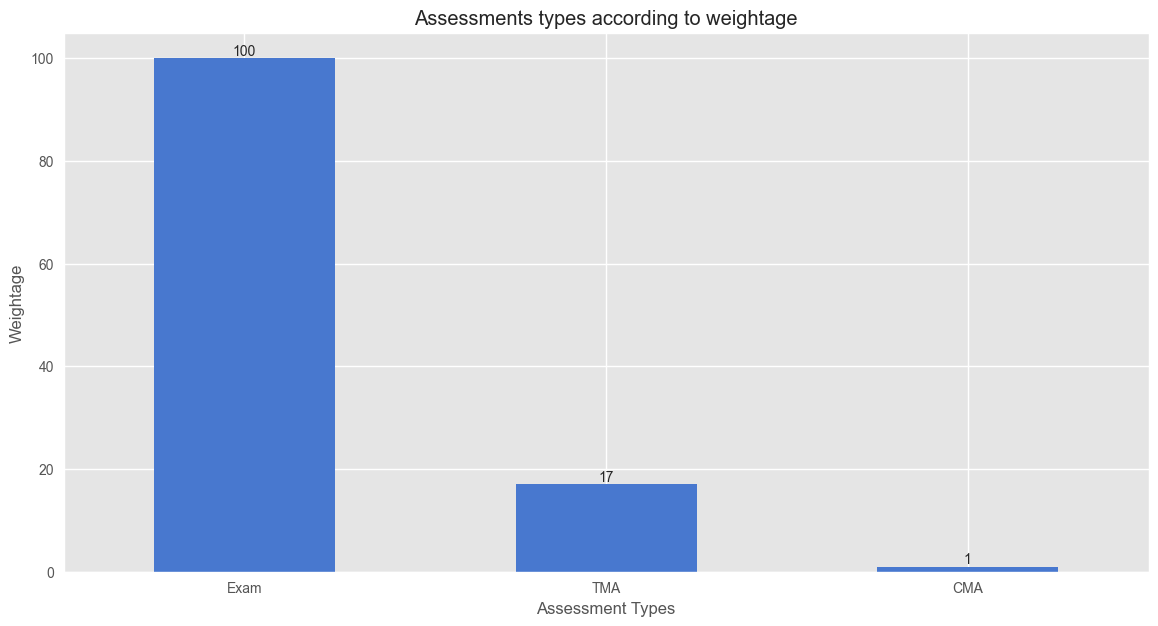

In [60]:
ax = most_weighted_assignemnts.plot(kind ='bar', figsize = (14,7))

ax.bar_label(ax.containers[0])

plt.title('Assessments types according to weightage')

plt.ylabel('Weightage')
plt.xlabel('Assessment Types')

plt.style.use('seaborn-v0_8')

plt.xticks(rotation = 0)

plt.show()

# `EDA DONE FOR assessments Table`

# `==========================================================================================================================
# ============================================================================================================================`

# `EDA ---> student_assessment Table`

In [61]:
# Total rows and columns

student_assessment.shape

(173912, 5)

In [62]:
# Overview of student_assessment Table

student_assessment.head(5)

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79


In [63]:
# Description and Statsics

student_assessment.describe().reset_index()

,index,id_assessment,id_student,date_submitted,is_banked
0,count,173912.000000,1.739120e+05,173912.000000,173912.000000
1,mean,26553.803556,7.051507e+05,116.032942,0.010977
2,std,8829.784254,5.523952e+05,71.484148,0.104194
3,min,1752.000000,6.516000e+03,-11.000000,0.000000
4,25%,15022.000000,5.044290e+05,51.000000,0.000000
5,50%,25359.000000,5.852080e+05,116.000000,0.000000
6,75%,34883.000000,6.344980e+05,173.000000,0.000000
7,max,37443.000000,2.698588e+06,608.000000,1.000000


In [64]:
# Info and data types

student_assessment.info()

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   id_assessment   173912 non-null  int64
 1   id_student      173912 non-null  int64
 2   date_submitted  173912 non-null  int64
 3   is_banked       173912 non-null  int64
 4   score           173912 non-null  str  
dtypes: int64(4), str(1)
memory usage: 6.6 MB


` 'score' column is showing it's data type as string and it's values are in numerical form and also decribe also did not show it 
it means there is some string values inside it `

In [65]:
student_assessment['score'] = student_assessment['score'].str.strip().replace('?', np.nan)

In [66]:
student_assessment['score'] = student_assessment['score'].astype('Int64')

In [67]:
# Verifying the data type int.

student_assessment['score'].info()

<class 'pandas.Series'>
RangeIndex: 173912 entries, 0 to 173911
Series name: score
Non-Null Count   Dtype
--------------   -----
173739 non-null  Int64
dtypes: Int64(1)
memory usage: 1.5 MB


In [68]:
# Checking for duplicates

student_assessment.duplicated().sum()

np.int64(0)

In [69]:
# checking for nulls

student_assessment.isnull().sum()

id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

### `There are no nulls in general and nulls in score column are delibrately put by me replacing the '?' `

# `Visualizations`

In [70]:
student_with_lower_score = student_assessment.groupby('id_student')['score'].mean().tail(10).sort_values(ascending=True).round()

student_with_lower_score

id_student
2698535    39.0
2698251    58.0
2698577    64.0
2698257    68.0
2697921    74.0
2697885    75.0
2698125    79.0
2697630    80.0
2697181    88.0
2698588    92.0
Name: score, dtype: Float64

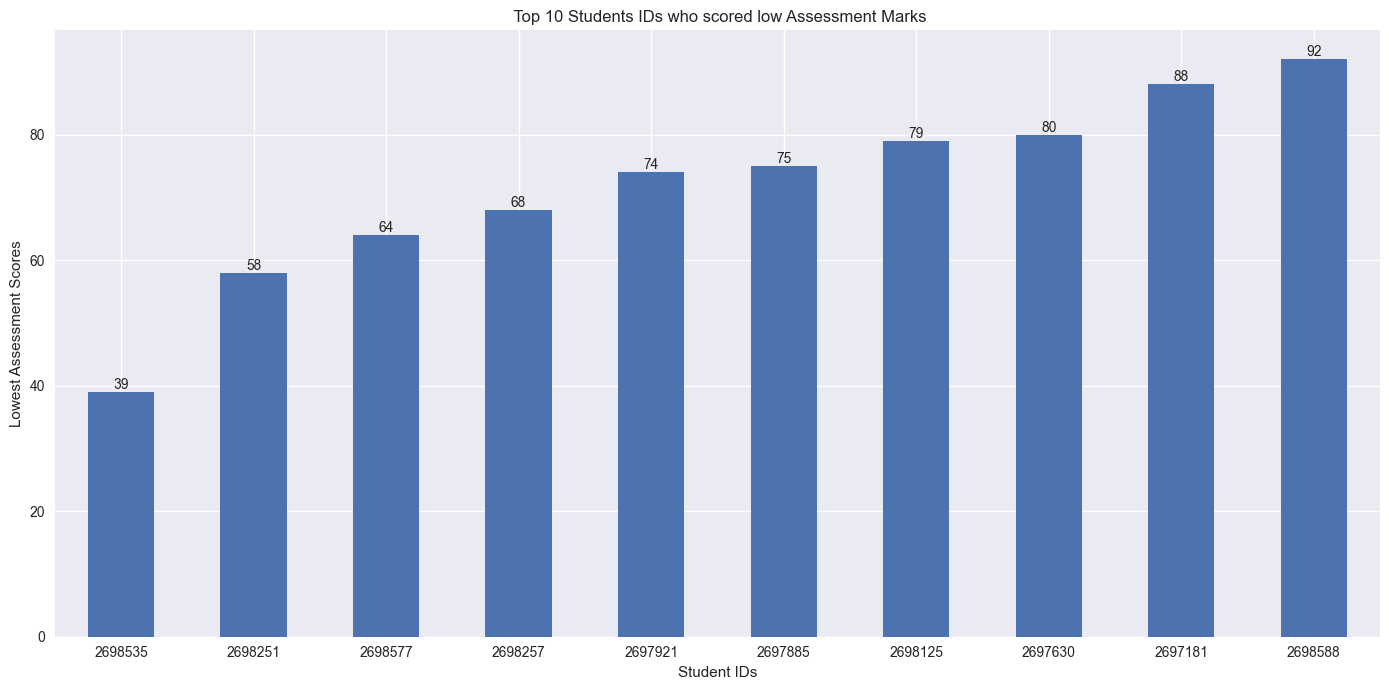

In [71]:
ax = student_with_lower_score.plot(kind = 'bar', figsize = (14,7))

ax.bar_label(ax.containers[0])

plt.title(' Top 10 Students IDs who scored low Assessment Marks')

plt.xlabel('Student IDs')
plt.ylabel('Lowest Assessment Scores')

plt.xticks(rotation = 0)

plt.style.use('seaborn-v0_8-muted')

plt.tight_layout()

plt.show()

# `EDA DONE FOR TABLE student_assessment`

# `======================================================================================================================
# =======================================================================================================================`

# Merging both Tables --> 'assessment' and 'student_assessment' Tables.

In [72]:
# Merging using `id_Assessment` as a comman column left join as student_Assessment table includes more rows and it is important.

assessment_tables_merged = pd.merge(student_assessment,assessments, on = ['id_assessment'], how = 'left')

In [73]:
# Overview of Merged Tables

assessment_tables_merged.head(8)

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78,AAA,2013J,TMA,19,10.0
1,1752,28400,22,0,70,AAA,2013J,TMA,19,10.0
2,1752,31604,17,0,72,AAA,2013J,TMA,19,10.0
3,1752,32885,26,0,69,AAA,2013J,TMA,19,10.0
4,1752,38053,19,0,79,AAA,2013J,TMA,19,10.0
5,1752,45462,20,0,70,AAA,2013J,TMA,19,10.0
6,1752,45642,18,0,72,AAA,2013J,TMA,19,10.0
7,1752,52130,19,0,72,AAA,2013J,TMA,19,10.0


# `Visualizations`

In [74]:
assessment_types_average_scores = assessment_tables_merged.groupby('assessment_type')['score'].mean().sort_values(ascending = False).round()

assessment_types_average_scores

assessment_type
CMA     81.0
TMA     73.0
Exam    66.0
Name: score, dtype: Float64

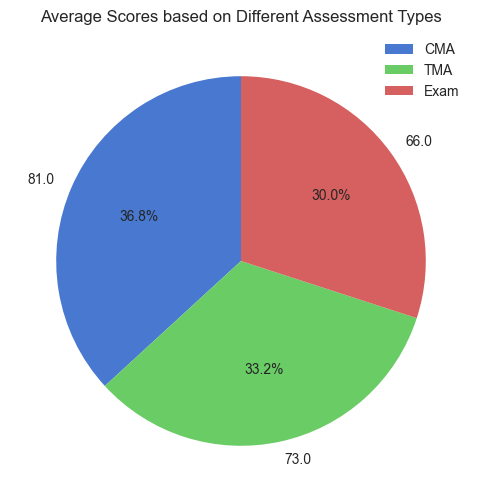

In [75]:
# Adding data lables

from cProfile import label


assessment_types_average_scores.plot(kind = 'pie', figsize = (6,6),autopct = '%1.1f%%', startangle = 90, labels = assessment_types_average_scores.values, ylabel= '')

plt.title('Average Scores based on Different Assessment Types')

plt.style.use('ggplot')

plt.legend(labels = assessment_types_average_scores.index, loc = 'upper right')

plt.show()

# `EDA DONE FOR assessments_tables_merged `

# `================================================================================================================================
# =================================================================================================================================`

# `EDA --> student_registration Table`

In [76]:
# Total rows and columns 

student_registration.shape

(32593, 5)

In [77]:
# Overview of student_registartion Table

student_registration.head(5)

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159,?
1,AAA,2013J,28400,-53,?
2,AAA,2013J,30268,-92,12
3,AAA,2013J,31604,-52,?
4,AAA,2013J,32885,-176,?


In [78]:
# Info and data types

student_registration.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   code_module          32593 non-null  str  
 1   code_presentation    32593 non-null  str  
 2   id_student           32593 non-null  int64
 3   date_registration    32593 non-null  str  
 4   date_unregistration  32593 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.2 MB


` columns --> date_Registartion and date_unregistration should be of int data type instead of str`

In [79]:
# Checking the reason 

student_registration[student_registration['date_registration'] == '?'].head(3)

,code_module,code_presentation,id_student,date_registration,date_unregistration
2344,BBB,2013B,630346,?,?
2538,BBB,2013J,57369,?,-1
2759,BBB,2013J,342678,?,-33


### `So there are ? in both last columns: date_registartion and date_unregistartion.

### ? in date_unregistartion means the student did not unregistered the course or module and completed it.

### ? in date_registration means the registartion of a student was corrupted or not tracked by the database.It is purely a 
### a data administartive issue.

`

In [80]:
# Replacing ? with np.nan and then converting the columns to Int64

student_registration['date_registration'] = student_registration['date_registration'].str.strip().replace('?', np.nan)

student_registration['date_unregistration'] = student_registration['date_unregistration'].str.strip().replace('?', np.nan)

In [81]:
student_registration['date_registration'] = student_registration['date_registration'].astype('Int64')

student_registration['date_unregistration'] = student_registration['date_unregistration'].astype('Int64')

In [82]:
# Verfying Data type

student_registration[['date_registration', 'date_unregistration']].info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   date_registration    32548 non-null  Int64
 1   date_unregistration  10072 non-null  Int64
dtypes: Int64(2)
memory usage: 573.1 KB


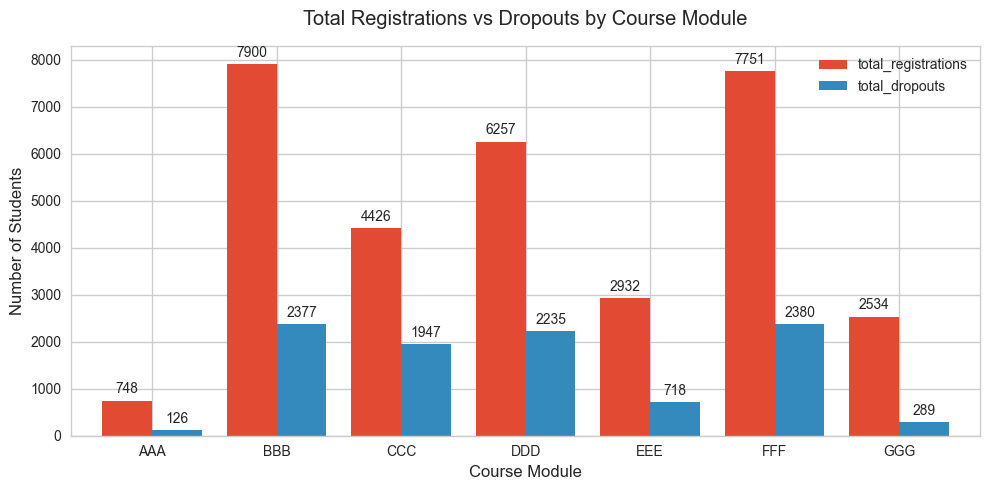

In [83]:
import matplotlib.pyplot as plt

# Step 1: Variable Creation
registration_summary = student_registration.groupby('code_module').agg(
    total_registrations=('date_registration', 'count'),
    total_dropouts=('date_unregistration', 'count')
)

# Step 2: Bar Plotting
plt.style.use('seaborn-v0_8-whitegrid')

ax = registration_summary.plot(kind='bar', figsize=(10, 5), width=0.8)

# Step 3: Add Labels & Formatting
ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)

plt.title('Total Registrations vs Dropouts by Course Module', pad=15)
plt.xlabel('Course Module')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# `EDA DONE FOR student_registartion Table`

# `======================================================================================================================
# ========================================================================================================================
# ========================================================================================================================
# ==========================================================================================================================`

In [84]:
'''Problem: 

vle_tables_merged aur assessment_tables_merged abhi bhi row-per-click aur row-per-assessment level pe hain 
(bahut saari rows per student). Inhe seedha student_info (jo row-per-student hai) ke saath merge nahi kar sakte — pehle inhe summarize karna padega 
(jaisa maine pehle discuss kiya tha).

'''

'Problem: \n\nvle_tables_merged aur assessment_tables_merged abhi bhi row-per-click aur row-per-assessment level pe hain \n(bahut saari rows per student). Inhe seedha student_info (jo row-per-student hai) ke saath merge nahi kar sakte — pehle inhe summarize karna padega \n(jaisa maine pehle discuss kiya tha).\n\n'

In [85]:
# Summarzing both merged vle tables. 

vle_tables = vle_tables_merged.groupby(['id_student','code_module','code_presentation']).agg(total_clicks=('sum_click','sum'), active_days=('date','nunique')).reset_index() # — ab ye bhi 1-row-per-student ban jaayega.

vle_tables.head(3)

,id_student,code_module,code_presentation,total_clicks,active_days
0,6516,AAA,2014J,2715,159
1,8462,DDD,2013J,634,56
2,8462,DDD,2014J,9,1


In [86]:
# Summarizing assessment emrged tables

assessment_tables = assessment_tables_merged.groupby(['id_student','code_module','code_presentation']).agg(avg_score=('score','mean'), total_assessments=('score','count')).reset_index() #  — isme code_module/code_presentation already hain kyunki assessments.csv se aaye the.

assessment_tables.head(3)

,id_student,code_module,code_presentation,avg_score,total_assessments
0,6516,AAA,2014J,61.8,5
1,8462,DDD,2013J,87.666667,3
2,8462,DDD,2014J,86.5,4


### `Reason for this Summarization` :

### `Machine Learning model ko har student ke liye sirf 1 row chahiye hoti hai prediction karne ke liye (Pass/Fail). Raw logs se aggregate metric nikalne ki iss process ko hi Summarization ya Feature Aggregation kehte hain.`

# `======================================================  =======================================================`

# `Merging  Tables`

### `Merging student_info() and course Tables.

In [87]:
final_table = pd.merge(student_info, course, on = ['code_module','code_presentation'], how = 'left')

final_table.head(3)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,268


### `Merging student_registration with final_table.`

In [88]:
final_table = pd.merge(final_table , student_registration, on=['id_student','code_module','code_presentation'], how='left')

final_table.head(5)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length,date_registration,date_unregistration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268,-159,<NA>
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268,-53,<NA>
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,268,-92,12
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,268,-52,<NA>
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,268,-176,<NA>


### `Merging vle_tables with final_table`

In [89]:
final_table = pd.merge(final_table, vle_tables, on = ['id_student','code_module','code_presentation'], how = 'left')

### `Merging assessment_tables with final_table`

In [90]:
final_table = pd.merge(final_table,  assessment_tables,  on = ['id_student','code_module','code_presentation'], how = 'left')

## `Overview of Final_Table after merging all the Tables.`

In [91]:
final_table.head(5)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length,date_registration,date_unregistration,total_clicks,active_days,avg_score,total_assessments
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268,-159,<NA>,922.0,40.0,82.0,5
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268,-53,<NA>,1409.0,80.0,66.4,5
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,268,-92,12,260.0,12.0,<NA>,<NA>
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,268,-52,<NA>,2007.0,123.0,76.0,5
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,268,-176,<NA>,1012.0,70.0,54.4,5


### `Total rows and columns : `

In [92]:
final_table.shape

(32593, 19)

### `Data Cleaning and Preprocessing :`

In [93]:
# Checking for duplicates

final_table.duplicated(subset = ['code_module', 'code_presentation', 'id_student']).sum()

np.int64(0)

`No Duplicates detected`

In [94]:
# Checking for Nulls

final_table.isnull().sum()

code_module                       0
code_presentation                 0
id_student                        0
gender                            0
region                            0
highest_education                 0
imd_band                          0
age_band                          0
num_of_prev_attempts              0
studied_credits                   0
disability                        0
final_result                      0
module_presentation_length        0
date_registration                45
date_unregistration           22521
total_clicks                   3365
active_days                    3365
avg_score                      6773
total_assessments              6750
dtype: int64

### `Fixing Nulls`

In [95]:

## Impute missing engagement and academic performance metrics with 0 (indicates no activity/submissions)

final_table['avg_score'] = final_table['avg_score'].fillna(0)

final_table['total_assessments'] = final_table['total_assessments'].fillna(0)

final_table['active_days'] = final_table['active_days'].fillna(0)

final_table['total_clicks'] = final_table['total_clicks'].fillna(0)

# Making a withdrew column with values of date_unregistration

final_table['withdrew'] = final_table['date_unregistration'].notnull().astype(int)

In [96]:
# Verifying

final_table.isnull().sum()

code_module                       0
code_presentation                 0
id_student                        0
gender                            0
region                            0
highest_education                 0
imd_band                          0
age_band                          0
num_of_prev_attempts              0
studied_credits                   0
disability                        0
final_result                      0
module_presentation_length        0
date_registration                45
date_unregistration           22521
total_clicks                      0
active_days                       0
avg_score                         0
total_assessments                 0
withdrew                          0
dtype: int64

In [97]:
# Dropping nulls in date_Registration

final_table = final_table.dropna(subset= ['date_registration'])

### `In date_unregistartion column : `
### ` Nulls in this are valid like they shows students which did not unregistered and competed the course.`

# `========================================================================================================================
# ==========================================================================================================================`

### `Checking final table which is going to be our target at risk.`

In [98]:
final_table['final_result'].value_counts().reset_index()

,final_result,count
0,Pass,12360
1,Withdrawn,10117
2,Fail,7047
3,Top Performer,3024


### `Risk Mapping categories like specially ``Fail``    `&`    ``Withdrawn``. `

In [99]:
# defining a small decitionary scores 1 and 0 to categories which will be shown in our new column --->  at risk.

risk_mapping = {'Pass': 0, 'Top Performer' : 0, 'Fail' : 1, 'Withdrawn' : 1}

final_table['at_risk'] = final_table['final_result'].map(risk_mapping)

In [100]:
# Verifying 

final_table['at_risk'].value_counts().reset_index()

,at_risk,count
0,1,17164
1,0,15384


In [101]:
# Checking nulls

final_table['at_risk'].isnull().sum()

np.int64(0)

In [102]:
# Overview 

final_table.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result',
       'module_presentation_length', 'date_registration',
       'date_unregistration', 'total_clicks', 'active_days', 'avg_score',
       'total_assessments', 'withdrew', 'at_risk'],
      dtype='str')

### `X (Input Features) aur y (Target/Answer) alag karna`


In [103]:
# Columns jo model ko bilkul nahi dikhani — IDs aur leakage wale columns

drop_columns = ['id_student','code_module','code_presentation','final_result','date_registration','date_unregistration','withdrew']

# X = final_table me se drop_cols aur at_risk (answer) hata ke jo bacha
x = final_table.drop(columns = drop_columns + ['at_risk'])

## y = sirf at_risk column — yahi model seekhega predict karna
y = final_table['at_risk']

#### `Columns like avg_score or total_assessments etc are given to the model for training and Y is answer column jo model dega `

In [104]:
# Checking answer column vairable.

y.value_counts()

at_risk
1    17164
0    15384
Name: count, dtype: int64

###  `==================================================================================================
###   ===================================================================================================`

### ` Now we will convert every column that we gave to the Model like -->  total_Assessment or total_click or avg_Score etc.  into numerical form  and`
### `we are doing this because the model only understand maths.`

### `Toh humein x ke text columns (gender, region, highest_education, imd_band, age_band, disability) ko 0/1 numbers me convert karna hai.`

In [105]:
# Overview of all the Columns in Model on the basis of which the model will make decisions.

x.columns

Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
       'num_of_prev_attempts', 'studied_credits', 'disability',
       'module_presentation_length', 'total_clicks', 'active_days',
       'avg_score', 'total_assessments'],
      dtype='str')

# `Converting only Text columns into Numerical form because Int columns are already in Numerical form` 
## `The Model will show True and False instead of 1 and 0`

### `True --> 1    and    False --> 0`

In [106]:
x = pd.get_dummies(x, columns=['gender', 'region', 'highest_education', 
                                 'imd_band', 'age_band', 'disability'], 
                    drop_first=True)

In [107]:
# Overview After conversion

x.head(3)

,num_of_prev_attempts,studied_credits,module_presentation_length,total_clicks,active_days,avg_score,total_assessments,gender_M,region_East Midlands Region,region_Ireland,...,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,disability_Y
0,0,240,268,922.0,40.0,82.0,5,True,False,False,...,False,False,False,False,False,True,False,False,True,False
1,0,60,268,1409.0,80.0,66.4,5,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0,60,268,260.0,12.0,0.0,0,False,False,False,...,False,False,False,False,False,False,False,True,False,True


# `Importing scikit learn library now.`

In [108]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### `Libraries explanation : `

In [109]:
# --- Machine Learning Libraries ---

# RandomForestClassifier -> humara model hai. Bahut saare decision trees banata hai,
#                            aur har tree ki "vote" milake final prediction deta hai
#                            (jyada trees = jyada stable/accurate result)

#
# accuracy_score          -> test data pe kitna % predictions sahi aaye, wo batata hai


# classification_report   -> detailed report deta hai: precision, recall, f1-score
#                            (sirf overall accuracy nahi, balki "at_risk" wale students ko
#                            kitna sahi pakda gaya, wo bhi batata hai)


# confusion_matrix        -> chhoti table: kitne sahi predict hue, kitne galat
#                            (jaise "at_risk bola but tha nahi" ya "safe bola but tha risk me")

## `Splitting the Training Data that is the total rows of x into 2 Parts like 80% and 20%.`

### `Training data and testing data.`

### `we will use 80% Training data to train the model and then we would use 20% testing data to test the mdoel fairly`

In [110]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42, stratify = y )

`random_state = 42 seed fix kiya, taaki result har baar same aaye (re-run pe change na ho)`

`stratify=y         # train/test dono me at_risk ka 0/1 ratio same rakhta hai`

In [111]:
# Training The Model

Model = RandomForestClassifier(random_state= 42)

Model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# `Model is trained`
## `This n_estimators -> 100 which means the Model made 100 decision trees and the more decision trees the more stable prediction.`

### `=============================================================================================================================
### ================================================================================================================================
### ================================================================================================================================`

## `Making Prediction with test data of x_test.`

In [112]:
#  Making Prediction by giving Model the test data 

y_predict = Model.predict(x_test)


print(y_predict)

[0 1 1 ... 1 0 0]


### `Converting Predicted Output in Readable and Dataframe format.`

In [128]:
Predicted_output = pd.DataFrame({
    'id_student' :  final_table.loc[y_test.index, 'id_student'],
    'actual' : y_test,
    'predicted' : y_predict
})


Predicted_output.head(10).reset_index()

,index,id_student,actual,predicted
0,31763,634258,0,0
1,20925,628054,1,1
2,28480,624740,1,1
3,2914,440563,0,0
4,30136,387550,1,1
5,27634,2462281,1,1
6,18831,678233,0,0
7,23053,528517,0,0
8,1087,409662,0,0
9,29186,674657,0,0


In [ ]:
# Example for a particular student prediction

Predicted_output[Predicted_output['id_student'] == 674657]

,id_student,actual,predicted
29186,674657,0,0


## `In this output`:

### `In actual column is the result that we never gave to the Model. It was in the Final_Result column means`:
### `Pass or Top Performer ---> 0  &  Fail or withdrew ---> 1`

### `In predicted column, the values are given by the Model based on Training Data.`

### `=================================================================================================================================
### =======================================================================================================================================`

## `Checking Model Accuracy `

### `This accuracy score will tell us how much the model predicted right in 20% test data`

In [116]:
accuracy = accuracy_score(y_test, y_predict)   # y_test is the actual result which we did not gave him and y_predict is the predection he made

print('Accuracy_Score --> ', accuracy)

Accuracy_Score -->  0.9044546850998464


## `Classification Report`

### `It will give us Detailed Report — Precision, Recall, F1-score`

In [119]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3077
           1       0.95      0.87      0.91      3433

    accuracy                           0.90      6510
   macro avg       0.91      0.91      0.90      6510
weighted avg       0.91      0.90      0.90      6510



## `Confusion Matrix`

### `It will give us how much predicted correct and how much wrong`

In [122]:
confusion_matrix(y_test, y_predict)

array([[2904,  173],
       [ 449, 2984]])